In [108]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# Specifications
fs = 10000        # Sampling frequency (Hz)
cutoff = 1000     # Cutoff frequency (Hz)
num_taps = 100    # Number of filter taps

# Normalize cutoff frequency (0 to 1, where 1 = fs/2)
nyquist = fs / 2
normalized_cutoff = cutoff / nyquist

# Design the filter (equivalent to MATLAB's fir1)
filter_coefficients = signal.firwin(num_taps, normalized_cutoff)

# Display the coefficients
print("Filter Coefficients:")
print(filter_coefficients)


Filter Coefficients:
[-1.59218611e-04 -4.30359456e-04 -5.61775255e-04 -4.89840873e-04
 -2.05138661e-04  2.27954566e-04  6.69705997e-04  9.35068105e-04
  8.57842323e-04  3.72230362e-04 -4.22936842e-04 -1.25690281e-03
 -1.76050993e-03 -1.61030624e-03 -6.93627792e-04  7.80061826e-04
  2.29029732e-03  3.16604226e-03  2.85684092e-03  1.21395713e-03
 -1.34722713e-03 -3.90545357e-03 -5.33416973e-03 -4.75948674e-03
 -2.00167138e-03  2.20073166e-03  6.32676722e-03  8.57892909e-03
  7.60816073e-03  3.18414006e-03 -3.48824885e-03 -1.00061473e-02
 -1.35587458e-02 -1.20362473e-02 -5.05169320e-03  5.56163408e-03
  1.60719426e-02  2.20021749e-02  1.97997386e-02  8.45913864e-03
 -9.52904861e-03 -2.83612130e-02 -4.03338357e-02 -3.81486832e-02
 -1.74151873e-02  2.14846298e-02  7.28584291e-02  1.26785617e-01
  1.71588241e-01  1.96987400e-01  1.96987400e-01  1.71588241e-01
  1.26785617e-01  7.28584291e-02  2.14846298e-02 -1.74151873e-02
 -3.81486832e-02 -4.03338357e-02 -2.83612130e-02 -9.52904861e-03
  8.

In [111]:
def round_to_int(num):
    int_num = int(num) 
    frac = abs(num - int_num) 
    if frac >= 0.5:
        return int_num + 1 if num >= 0 else int_num - 1
    return int_num
def decToBinary(dec,m,n):
   return np.binary_repr(dec,m+n)
def fixedPoint(num, m, n):
  scale = 2**n
  fixed_int = round_to_int(num*scale)
  return decToBinary(fixed_int,m,n)
def quantize(samples,m,n):
  arr = []
  for i in range(len(samples)):
    arr.append(fixedPoint(samples[i],m,n))
  arr = np.array(arr)
  return arr

In [171]:
fc = np.array(filter_coefficients)
fc_quantized = quantize(fc,2,14)
np.savetxt('fc_quantized_2_14.txt',fc_quantized,fmt='%s')

In [172]:
ncycles = 100
def sampleVal(i,f,fs):
    Ts = 1/fs
    return np.sin(2*np.pi*f*i*Ts)
def sampleSineWave(f,fs,fname):
    arr = []
    t = np.arange(0,ncycles/f,1/fs)
    for i in range(len(t)):
        arr.append(sampleVal(i,f,fs))
    arr = np.array(arr)
    qarr = quantize(arr,2,14)
    np.savetxt(fname,qarr,fmt='%s')
def sampleSineWave_uq(f,fs,fname):
    t = np.arange(0,ncycles/f,1/fs)
    arr = []
    for i in range(len(t)):
        arr.append(sampleVal(i,f,fs))
    arr = np.array(arr)
    np.savetxt(fname,arr,fmt='%s')


In [173]:
fs = 10000
sampleSineWave(950,fs,"q_2_14_950.txt")
sampleSineWave(1100,fs,"q_2_14_1100.txt")
sampleSineWave(2000,fs,"q_2_14_2000.txt")
# sampleSineWave_uq(950,fs,"q_2_14_950_uq.txt")

In [127]:
def q_2_14_to_float(b_str):
    int_val = int(b_str, 2)
    
    # Handle negative numbers (two's complement)
    if b_str[0] == '1':  # MSB is 1 -> negative
        int_val -= (1 << 16)  # Subtract 2^16
    
    # Scale by 2^-14 to get float value
    float_val = int_val / (2 ** 14)
    
    return float_val

In [141]:
quantized_sines = []
sine_950 = np.loadtxt("q_2_14_950.txt",dtype='U16')
sine_1100 = np.loadtxt("q_2_14_1100.txt",dtype='U16')
sine_2000 = np.loadtxt("q_2_14_2000.txt",dtype='U16')
quantized_sines.append(sine_950)
quantized_sines.append(sine_1100)
quantized_sines.append(sine_2000)


for i in range(3):
    sine_arr = quantized_sines[i]
    for j in range(len(sine_arr)):
        sine_arr[j] = q_2_14_to_float(sine_arr[j])

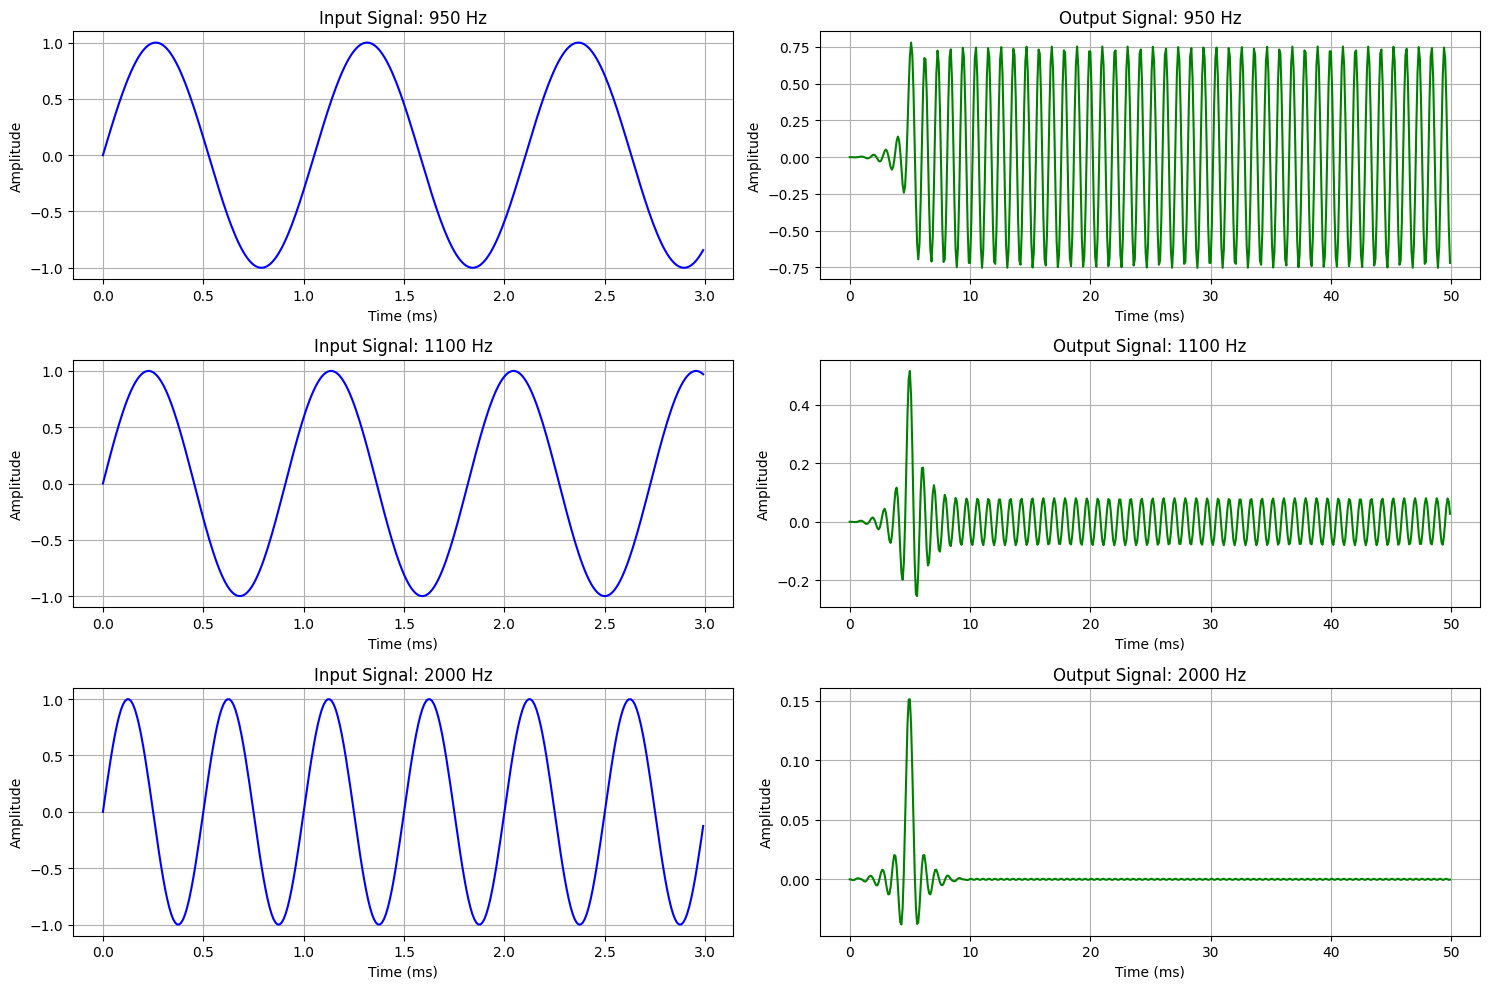

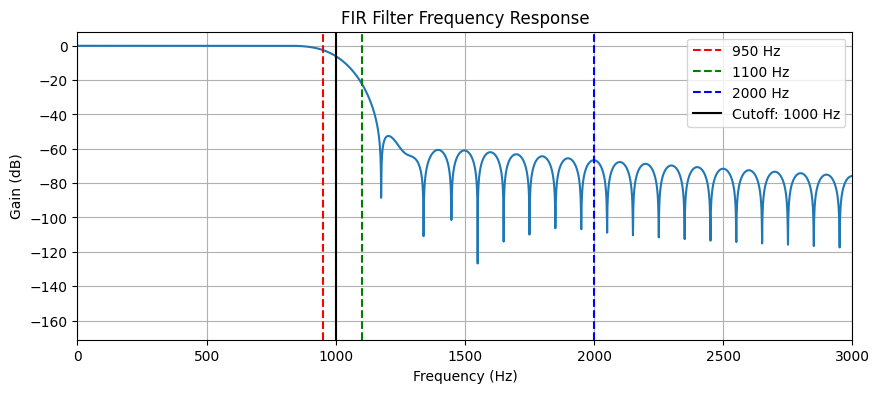

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
freqs = [950, 1100, 2000]
outputs = []

# Design a simple lowpass FIR filter (using window method)
cutoff = 1000  # Hz
nyquist = fs / 2
normal_cutoff = cutoff / nyquist

def fir_filter(b, x):
    """
    Direct Form FIR filter implementation
    
    b: filter coefficients (numerator only)
    x: input signal
    
    Returns filtered output y (convolution of x and b)
    """
    L = len(b)  # Filter length
    y = np.zeros(len(x))
    
    # Simple convolution (direct form)
    for n in range(len(x)):
        for k in range(L):
                y[n] += b[k] * (x[n-k] if n-k >= 0 else 0)
    
    return y

t_plot = np.arange(0, 0.05, 1/(fs*10))


plt.figure(figsize=(15, 10))

for i, f in enumerate(freqs):
    # Generate at FILTER rate
    
    # Apply FIR filter using direct form
    output = fir_filter(filter_coefficients, quantized_sines[i].astype(float))
    outputs.append(output)
    
    # Generate at PLOT rate for smooth input display
    sine_wave_plot = np.sin(2 * np.pi * f * t_plot)
    
    # Plot smooth input
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(t_plot[:300]*1000, sine_wave_plot[:300], 'b-')
    plt.title(f'Input Signal: {f} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    
    # Plot output (at filter rate)
    plt.subplot(3, 2, 2*i + 2)
    plt.plot(t_filter[:500]*1000, output[:500], 'g-')
    plt.title(f'Output Signal: {f} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Frequency response
plt.figure(figsize=(10, 4))
w, h = signal.freqz(filter_coefficients, worN=8000)
freq_hz = w * fs / (2 * np.pi)
plt.plot(freq_hz, 20 * np.log10(np.abs(h)))
plt.axvline(950, color='r', linestyle='--', label='950 Hz')
plt.axvline(1100, color='g', linestyle='--', label='1100 Hz')
plt.axvline(2000, color='b', linestyle='--', label='2000 Hz')
plt.axvline(1000, color='k', linestyle='-', label='Cutoff: 1000 Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.title('FIR Filter Frequency Response')
plt.grid(True)
plt.legend()
plt.xlim(0, 3000)
plt.show()

In [143]:
for i,f in enumerate(freqs):
    el = outputs[i]
    arr = []
    for i in range(500):
        arr.append(fixedPoint(el[i],12,28))
    arr = np.array(arr)
    np.savetxt(f'{f}_filtered.txt',arr,fmt='%s')

In [144]:
def twos_comp_to_int(binary_str):
    bits = len(binary_str)
    val = int(binary_str, 2)
    if binary_str[0] == '1': 
        val -= (1 << bits)
    return val

def int_to_twos_comp(val, bits):
    if val < 0:
        val += (1 << bits)
    return format(val, f'0{bits}b')

def val(str,scale):
      return twos_comp_to_int(str) / scale
def dequantize(arr, m, n):
    scale = 2**n
    out = []
    for i in range(len(arr)):
        str = arr[i]
        float_val = val(str,scale)
        out.append(float_val)
    
    return np.array(out)


In [191]:
verilog_950 = np.loadtxt("out_950_verilog.txt",dtype='U16')[3:,]
verilog_1100 = np.loadtxt("out_1100_verilog.txt",dtype='U16')[3:,]
verilog_2000 = np.loadtxt("out_2000_verilog.txt",dtype='U16')[3:,]
python_950 = np.loadtxt("950_filtered.txt",dtype='U16')
python_1100 = np.loadtxt("1100_filtered.txt",dtype='U16')
python_2000 = np.loadtxt("2000_filtered.txt",dtype='U16')
verilog_950 = dequantize(verilog_950, 12, 28)
verilog_1100 = dequantize(verilog_1100, 12, 28)
verilog_2000 = dequantize(verilog_2000, 12, 28)
python_950 = dequantize(python_950, 12, 28)
python_1100 = dequantize(python_1100, 12, 28)
python_2000 = dequantize(python_2000, 12, 28)

# print(np.isclose(verilog_950, python_950, atol=1e-7))
# print(np.isclose(verilog_1100, python_1100, atol=1e-7))
# print(np.isclose(verilog_2000, python_2000, atol=1e-7))